In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [8]:
adelie = pd.read_csv(r"D:\edalab\penguins\table_219.csv")
gentoo = pd.read_csv(r"D:\edalab\penguins\table_220.csv")
chinstrap = pd.read_csv(r"D:\edalab\penguins\table_221.csv")

In [9]:
adelie['species'] = 'Adelie'
gentoo['species'] = 'Gentoo'
chinstrap['species'] = 'Chinstrap'

In [10]:
penguins = pd.concat([adelie, gentoo, chinstrap], ignore_index=True)
print(penguins.head())
print(penguins.info())

  studyName  Sample Number                              Species  Region  \
0   PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1   PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2   PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3   PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4   PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   

      Island               Stage Individual ID Clutch Completion    Date Egg  \
0  Torgersen  Adult, 1 Egg Stage          N1A1               Yes  2007-11-11   
1  Torgersen  Adult, 1 Egg Stage          N1A2               Yes  2007-11-11   
2  Torgersen  Adult, 1 Egg Stage          N2A1               Yes  2007-11-16   
3  Torgersen  Adult, 1 Egg Stage          N2A2               Yes  2007-11-16   
4  Torgersen  Adult, 1 Egg Stage          N3A1               Yes  2007-11-16   

   Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  Body 

In [10]:
penguins.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments,species
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.,Adelie
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN,Adelie
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN,Adelie
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.,Adelie
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN,Adelie


In [11]:
penguins.shape

(344, 18)

In [13]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

In [14]:
penguins.describe()

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.430199,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.000000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.250000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


In [15]:
penguins.duplicated().sum()

0

In [16]:
for column in penguins.select_dtypes(include=['object']).columns:
    print(f"Unique values in '{column}': {penguins[column].value_counts()}")

Unique values in 'studyName': studyName
PAL0910    120
PAL0809    114
PAL0708    110
Name: count, dtype: int64
Unique values in 'Species': Species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64
Unique values in 'Region': Region
Anvers    344
Name: count, dtype: int64
Unique values in 'Island': Island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
Unique values in 'Stage': Stage
Adult, 1 Egg Stage    344
Name: count, dtype: int64
Unique values in 'Individual ID': Individual ID
N61A2     3
N29A2     3
N22A1     3
N22A2     3
N23A1     3
         ..
N84A2     1
N84A1     1
N83A2     1
N83A1     1
N100A2    1
Name: count, Length: 190, dtype: int64
Unique values in 'Clutch Completion': Clutch Completion
Yes    308
No      36
Name: count, dtype: int64
Unique values in 'Date Egg': Date Egg
2007-11-27    18
2008-11-09    16
2007-11-16    16

In [17]:
penguins.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments', 'species'],
      dtype='object')

In [18]:
penguins.drop(columns=[ 'Sample Number','Region','Stage', 'Date Egg', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'], inplace=True)

In [19]:
penguins.head() 

,studyName,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,species
0,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A1,Yes,39.1,18.7,181.0,3750.0,MALE,Adelie
1,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A2,Yes,39.5,17.4,186.0,3800.0,FEMALE,Adelie
2,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A1,Yes,40.3,18.0,195.0,3250.0,FEMALE,Adelie
3,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A2,Yes,NaN,NaN,NaN,NaN,NaN,Adelie
4,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N3A1,Yes,36.7,19.3,193.0,3450.0,FEMALE,Adelie


In [20]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Species              344 non-null    object 
 2   Island               344 non-null    object 
 3   Individual ID        344 non-null    object 
 4   Clutch Completion    344 non-null    object 
 5   Culmen Length (mm)   342 non-null    float64
 6   Culmen Depth (mm)    342 non-null    float64
 7   Flipper Length (mm)  342 non-null    float64
 8   Body Mass (g)        342 non-null    float64
 9   Sex                  334 non-null    object 
 10  species              344 non-null    object 
dtypes: float64(4), object(7)
memory usage: 29.7+ KB


In [21]:
penguins[penguins.isnull().any(axis=1)]

,studyName,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,species
3,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A2,Yes,NaN,NaN,NaN,NaN,NaN,Adelie
8,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N5A1,Yes,34.1,18.1,193.0,3475.0,NaN,Adelie
9,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N5A2,Yes,42.0,20.2,190.0,4250.0,NaN,Adelie
10,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N6A1,Yes,37.8,17.1,186.0,3300.0,NaN,Adelie
11,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N6A2,Yes,37.8,17.3,180.0,3700.0,NaN,Adelie
47,PAL0708,Adelie Penguin (Pygoscelis adeliae),Dream,N29A2,Yes,37.5,18.9,179.0,2975.0,NaN,Adelie
178,PAL0708,Gentoo penguin (Pygoscelis papua),Biscoe,N46A1,Yes,44.5,14.3,216.0,4100.0,NaN,Gentoo
218,PAL0809,Gentoo penguin (Pygoscelis papua),Biscoe,N51A1,Yes,46.2,14.4,214.0,4650.0,NaN,Gentoo
256,PAL0910,Gentoo penguin (Pygoscelis papua),Biscoe,N24A1,Yes,47.3,13.8,216.0,4725.0,NaN,Gentoo
271,PAL0910,Gentoo penguin (Pygoscelis papua),Biscoe,N38A2,No,NaN,NaN,NaN,NaN,NaN,Gentoo


In [22]:
penguins.dropna(inplace=True, axis=0,subset=[ 'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'])

In [23]:
penguins[penguins.isnull().any(axis=1)]

,studyName,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,species
8,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N5A1,Yes,34.1,18.1,193.0,3475.0,NaN,Adelie
9,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N5A2,Yes,42.0,20.2,190.0,4250.0,NaN,Adelie
10,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N6A1,Yes,37.8,17.1,186.0,3300.0,NaN,Adelie
11,PAL0708,Adelie Penguin (Pygoscelis adeliae),Torgersen,N6A2,Yes,37.8,17.3,180.0,3700.0,NaN,Adelie
47,PAL0708,Adelie Penguin (Pygoscelis adeliae),Dream,N29A2,Yes,37.5,18.9,179.0,2975.0,NaN,Adelie
178,PAL0708,Gentoo penguin (Pygoscelis papua),Biscoe,N46A1,Yes,44.5,14.3,216.0,4100.0,NaN,Gentoo
218,PAL0809,Gentoo penguin (Pygoscelis papua),Biscoe,N51A1,Yes,46.2,14.4,214.0,4650.0,NaN,Gentoo
256,PAL0910,Gentoo penguin (Pygoscelis papua),Biscoe,N24A1,Yes,47.3,13.8,216.0,4725.0,NaN,Gentoo


In [24]:
penguins[penguins['Individual ID']=='N24A1']

,studyName,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,species
36,PAL0708,Adelie Penguin (Pygoscelis adeliae),Dream,N24A1,Yes,38.8,20.0,190.0,3950.0,MALE,Adelie
56,PAL0809,Adelie Penguin (Pygoscelis adeliae),Biscoe,N24A1,Yes,39.0,17.5,186.0,3550.0,FEMALE,Adelie
256,PAL0910,Gentoo penguin (Pygoscelis papua),Biscoe,N24A1,Yes,47.3,13.8,216.0,4725.0,NaN,Gentoo


In [25]:
penguins[penguins['Individual ID']=='N24A2']

,studyName,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,species
37,PAL0708,Adelie Penguin (Pygoscelis adeliae),Dream,N24A2,Yes,42.2,18.5,180.0,3550.0,FEMALE,Adelie
57,PAL0809,Adelie Penguin (Pygoscelis adeliae),Biscoe,N24A2,Yes,40.6,18.8,193.0,3800.0,MALE,Adelie
257,PAL0910,Gentoo penguin (Pygoscelis papua),Biscoe,N24A2,Yes,46.8,16.1,215.0,5500.0,MALE,Gentoo


In [26]:
penguins.dropna(inplace=True)

In [27]:
penguins.columns

Index(['studyName', 'Species', 'Island', 'Individual ID', 'Clutch Completion',
       'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
       'Body Mass (g)', 'Sex', 'species'],
      dtype='object')

In [28]:
penguins.drop(columns=['studyName', 'Individual ID'], inplace=True)

In [29]:
penguins.head()

,Species,Island,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,species
0,Adelie Penguin (Pygoscelis adeliae),Torgersen,Yes,39.1,18.7,181.0,3750.0,MALE,Adelie
1,Adelie Penguin (Pygoscelis adeliae),Torgersen,Yes,39.5,17.4,186.0,3800.0,FEMALE,Adelie
2,Adelie Penguin (Pygoscelis adeliae),Torgersen,Yes,40.3,18.0,195.0,3250.0,FEMALE,Adelie
4,Adelie Penguin (Pygoscelis adeliae),Torgersen,Yes,36.7,19.3,193.0,3450.0,FEMALE,Adelie
5,Adelie Penguin (Pygoscelis adeliae),Torgersen,Yes,39.3,20.6,190.0,3650.0,MALE,Adelie


In [30]:
penguins['Species']=penguins['Species'].apply(lambda x: x.split()[0])

In [31]:
penguins

,Species,Island,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,species
0,Adelie,Torgersen,Yes,39.1,18.7,181.0,3750.0,MALE,Adelie
1,Adelie,Torgersen,Yes,39.5,17.4,186.0,3800.0,FEMALE,Adelie
2,Adelie,Torgersen,Yes,40.3,18.0,195.0,3250.0,FEMALE,Adelie
4,Adelie,Torgersen,Yes,36.7,19.3,193.0,3450.0,FEMALE,Adelie
5,Adelie,Torgersen,Yes,39.3,20.6,190.0,3650.0,MALE,Adelie
...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,Yes,55.8,19.8,207.0,4000.0,MALE,Chinstrap
340,Chinstrap,Dream,No,43.5,18.1,202.0,3400.0,FEMALE,Chinstrap
341,Chinstrap,Dream,No,49.6,18.2,193.0,3775.0,MALE,Chinstrap
342,Chinstrap,Dream,Yes,50.8,19.0,210.0,4100.0,MALE,Chinstrap


## EDA

In [13]:
penguins['Species'] = penguins['Species'].replace({
    'Adelie Penguin (Pygoscelis adeliae)': 'Adelie',
    'Chinstrap penguin (Pygoscelis antarctica)': 'Chinstrap',
    'Gentoo penguin (Pygoscelis papua)': 'Gentoo'
})

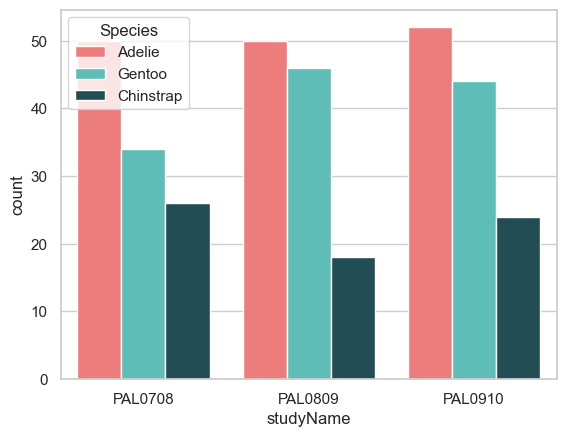

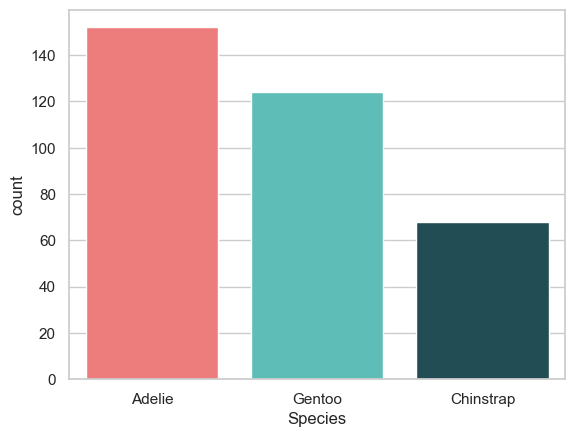

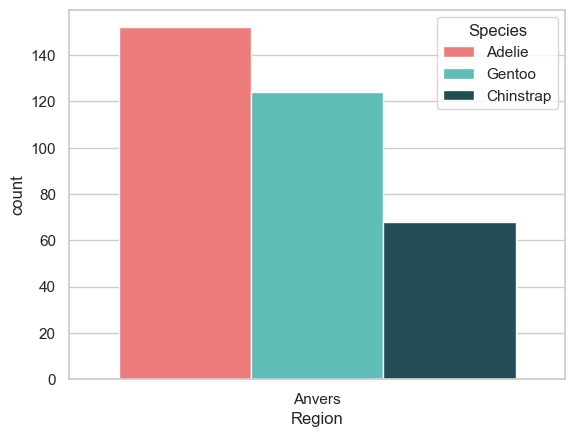

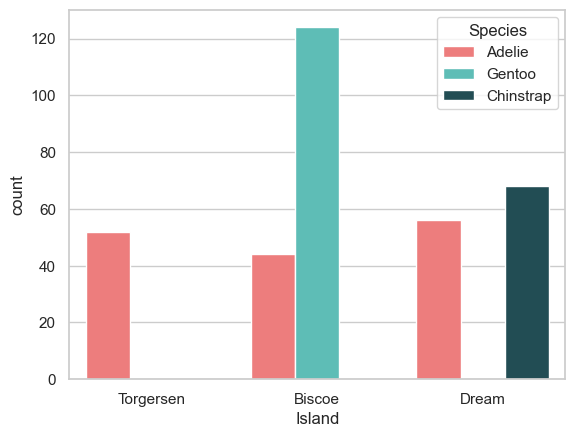

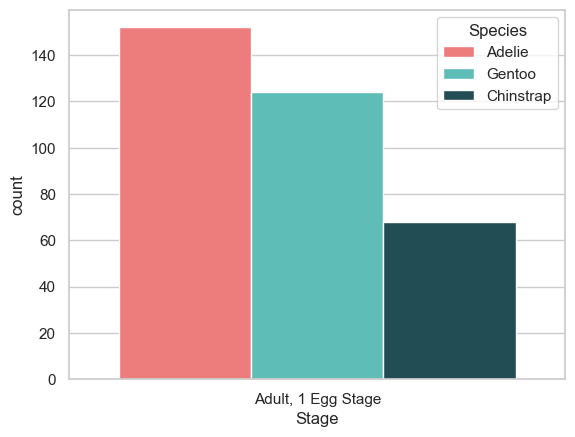

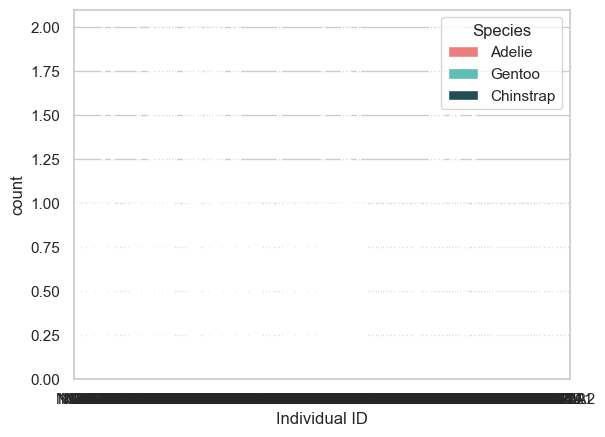

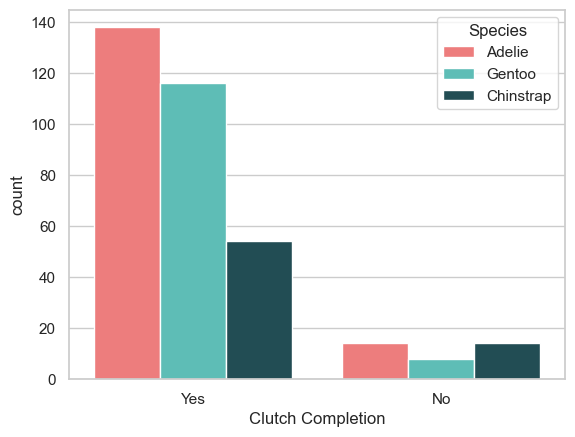

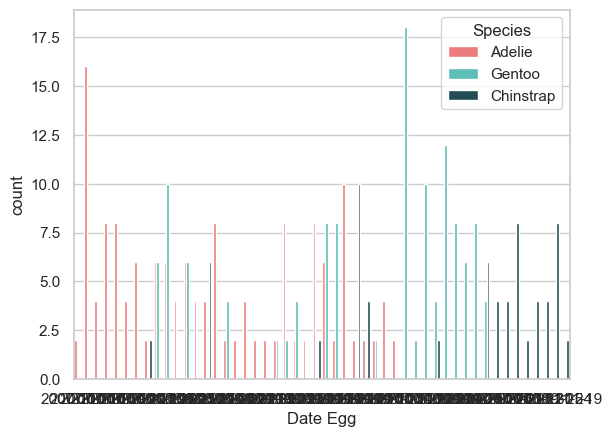

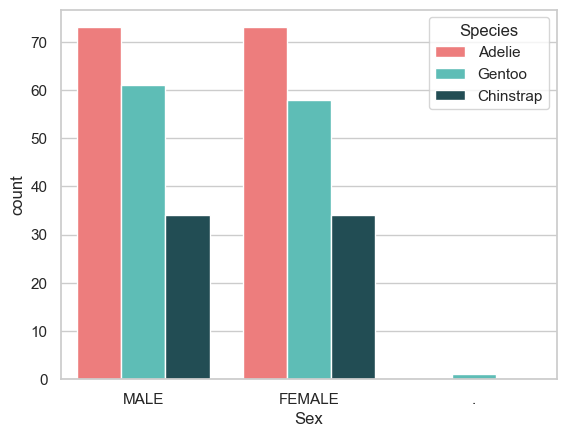

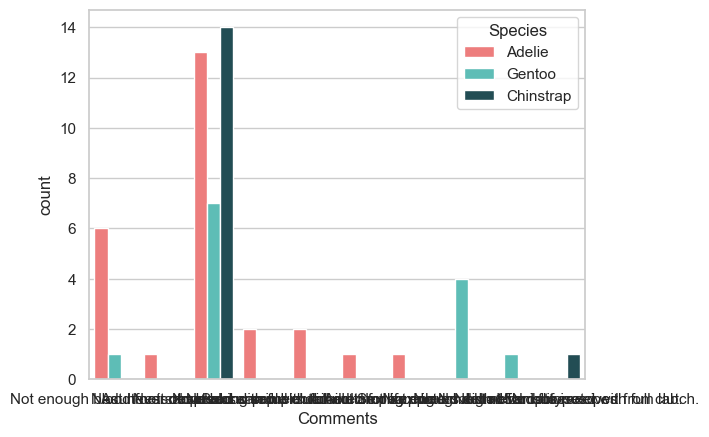

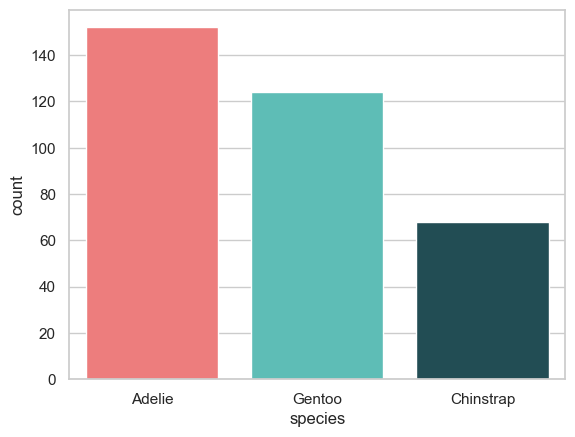

In [14]:
palette = {
    'Adelie': '#FF6B6B',
    'Gentoo': '#4ECDC4',
    'Chinstrap': '#1A535C'
}

for column in penguins.select_dtypes(include=['object']).columns:
    sns.countplot(
        data=penguins,
        x=column,
        hue='Species',
        palette=palette
    )
    plt.show()

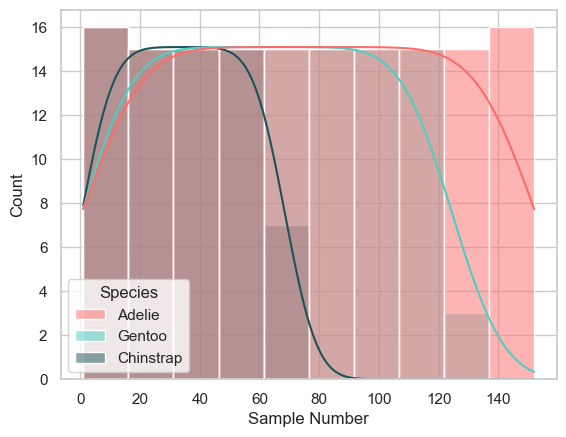

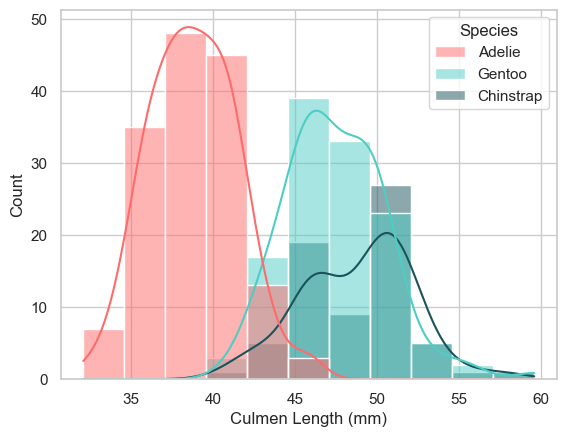

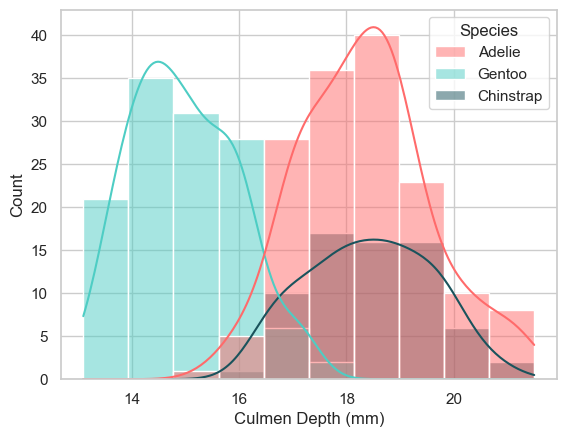

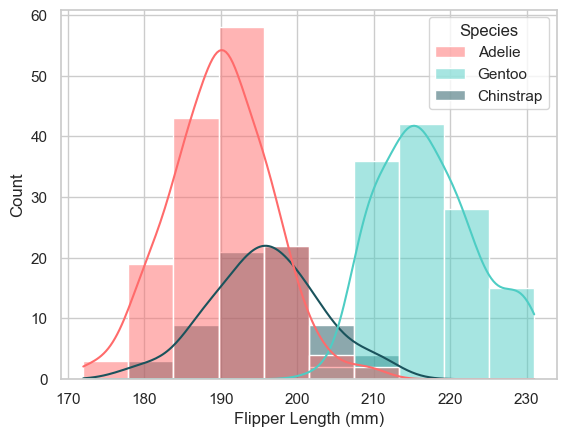

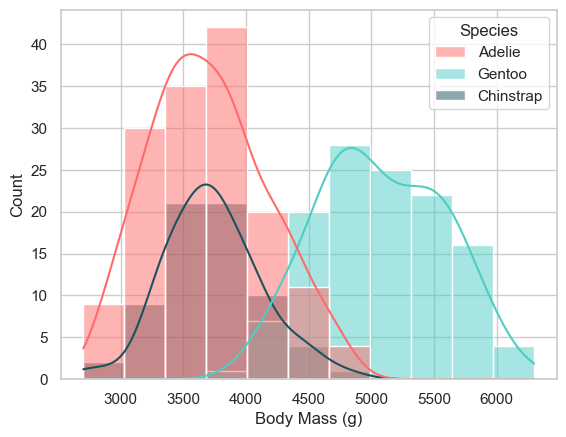

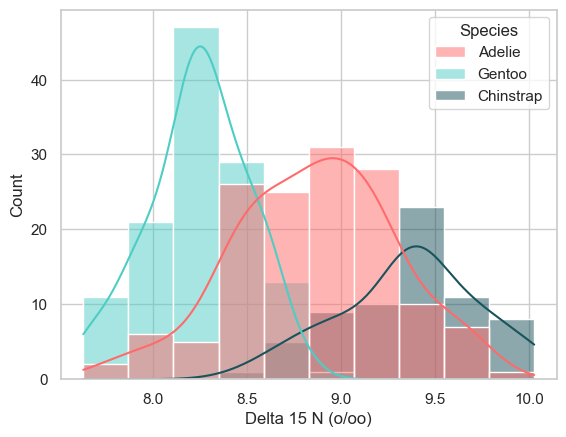

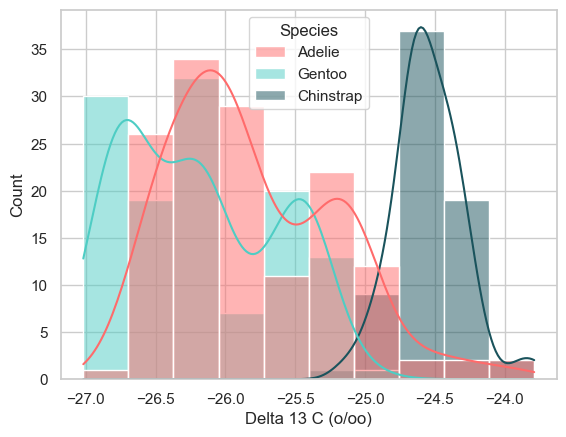

In [15]:
palette = {
    'Adelie': '#FF6B6B',
    'Gentoo': '#4ECDC4',
    'Chinstrap': '#1A535C'
}

for column in penguins.select_dtypes(include=['number']).columns:
    sns.histplot(
        data=penguins,
        x=column,
        hue='Species',
        kde=True,
        palette=palette
    )
    plt.show()

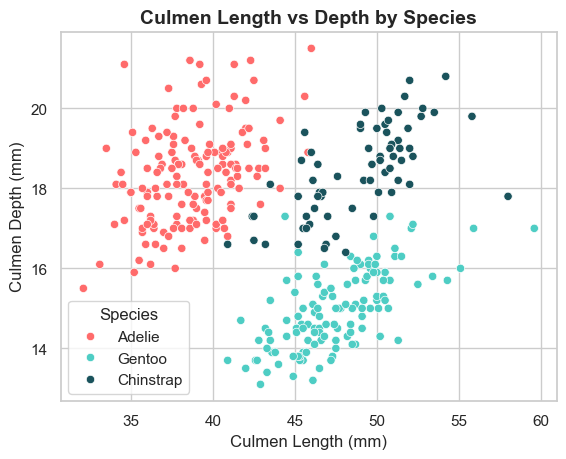

In [16]:
palette = {
    'Adelie': '#FF6B6B',
    'Gentoo': '#4ECDC4',
    'Chinstrap': '#1A535C'
}

sns.scatterplot(
    data=penguins,
    x='Culmen Length (mm)',
    y='Culmen Depth (mm)',
    hue='Species',
    palette=palette
)

plt.title("Culmen Length vs Depth by Species", fontsize=14, weight='bold')
plt.show()

In [37]:
penguins[['Culmen Depth (mm)','Culmen Length (mm)']].corr()

,Culmen Depth (mm),Culmen Length (mm)
Culmen Depth (mm),1.00000,-0.22864
Culmen Length (mm),-0.22864,1.00000


In [18]:
df_adelie=penguins[penguins['Species'] == 'Gentoo']

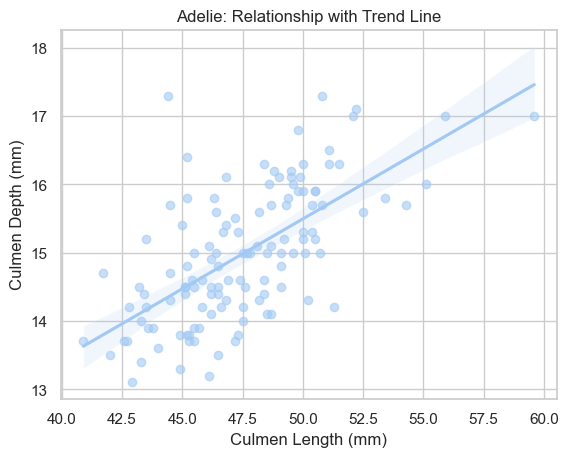

,Culmen Depth (mm),Culmen Length (mm)
Culmen Depth (mm),1.000000,0.643384
Culmen Length (mm),0.643384,1.000000


In [20]:
sns.regplot(
    data=df_adelie,
    x='Culmen Length (mm)',
    y='Culmen Depth (mm)',
    scatter_kws={'alpha':0.6}
)

plt.title("Adelie: Relationship with Trend Line")
plt.show()
df_adelie[['Culmen Depth (mm)', 'Culmen Length (mm)']].corr()

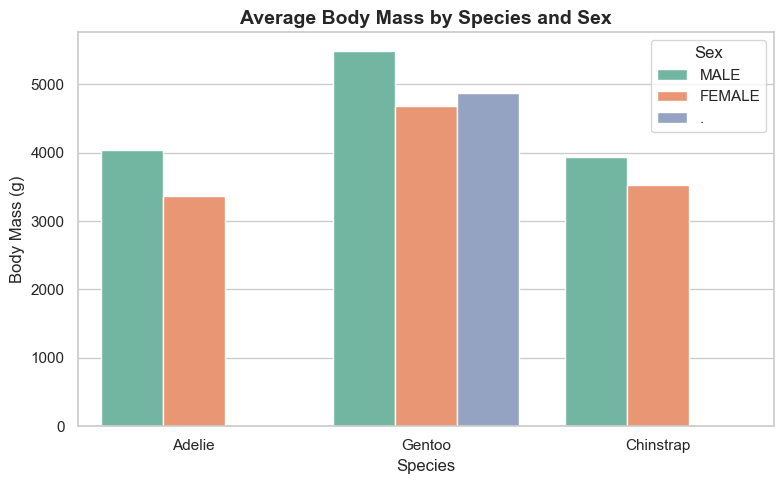

In [23]:
palette = {
    'Adelie': '#FF6B6B',
    'Gentoo': '#4ECDC4',
    'Chinstrap': '#1A535C'
}

plt.figure(figsize=(8,5))

sns.barplot(
    data=penguins,
    x='Species',
    y='Body Mass (g)',
    hue='Sex',
    palette='Set2',
    errorbar=None      
)

plt.title('Average Body Mass by Species and Sex', fontsize=14, weight='bold')
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.legend(title="Sex")

plt.tight_layout()
plt.show()

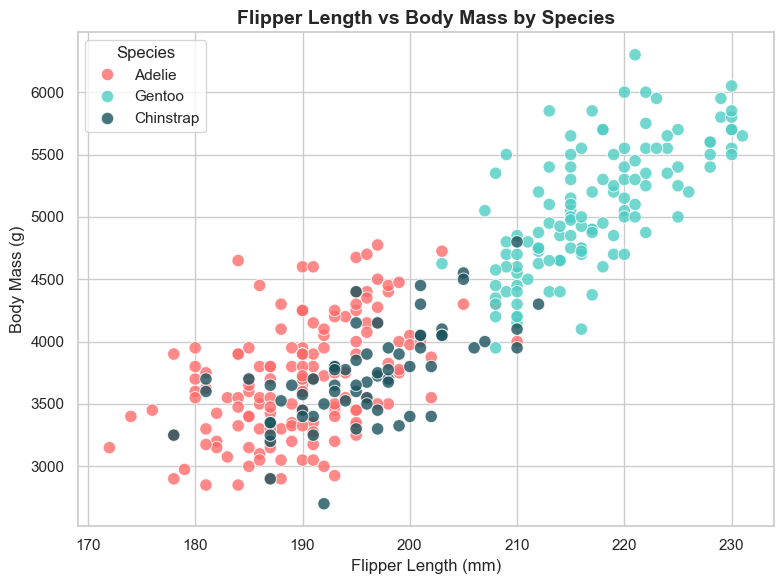

In [24]:
palette = {
    'Adelie': '#FF6B6B',
    'Gentoo': '#4ECDC4',
    'Chinstrap': '#1A535C'
}

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins,
    x='Flipper Length (mm)',
    y='Body Mass (g)',
    hue='Species',
    palette=palette,
    s=80,
    alpha=0.8
)

plt.title('Flipper Length vs Body Mass by Species', fontsize=14, weight='bold')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Species')

plt.tight_layout()
plt.show()

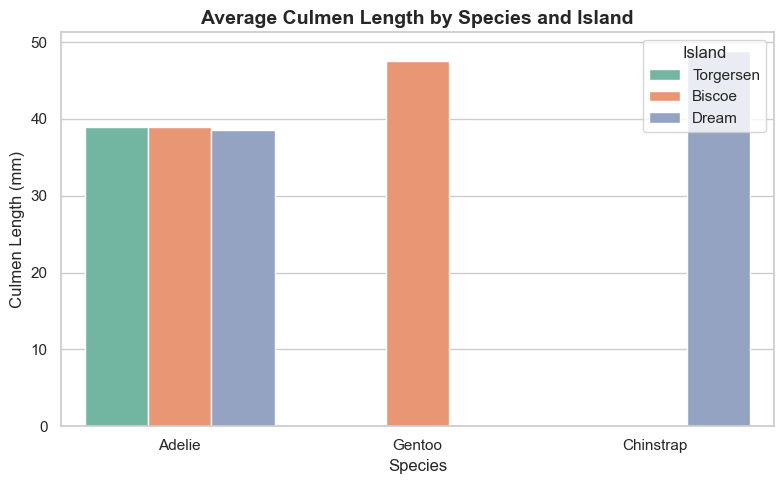

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=penguins,
    x='Species',
    y='Culmen Length (mm)',
    hue='Island',
    palette='Set2',
    errorbar=None
)

plt.title('Average Culmen Length by Species and Island', fontsize=14, weight='bold')
plt.xlabel('Species')
plt.ylabel('Culmen Length (mm)')
plt.legend(title='Island')

plt.tight_layout()
plt.show()

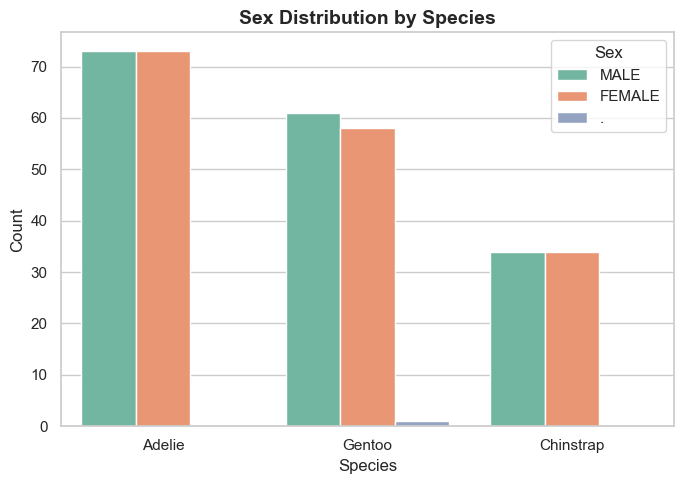

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=penguins,
    x='Species',
    hue='Sex',
    palette='Set2'
)

plt.title('Sex Distribution by Species', fontsize=14, weight='bold')
plt.xlabel('Species')
plt.ylabel('Count')
plt.legend(title='Sex')

plt.tight_layout()
plt.show()

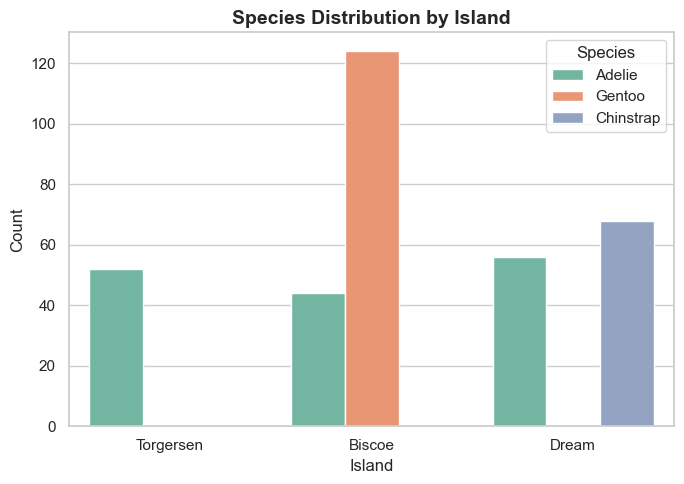

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=penguins,
    x='Island',
    hue='Species',
    palette='Set2'
)

plt.title('Species Distribution by Island', fontsize=14, weight='bold')
plt.xlabel('Island')
plt.ylabel('Count')
plt.legend(title='Species')

plt.tight_layout()
plt.show()

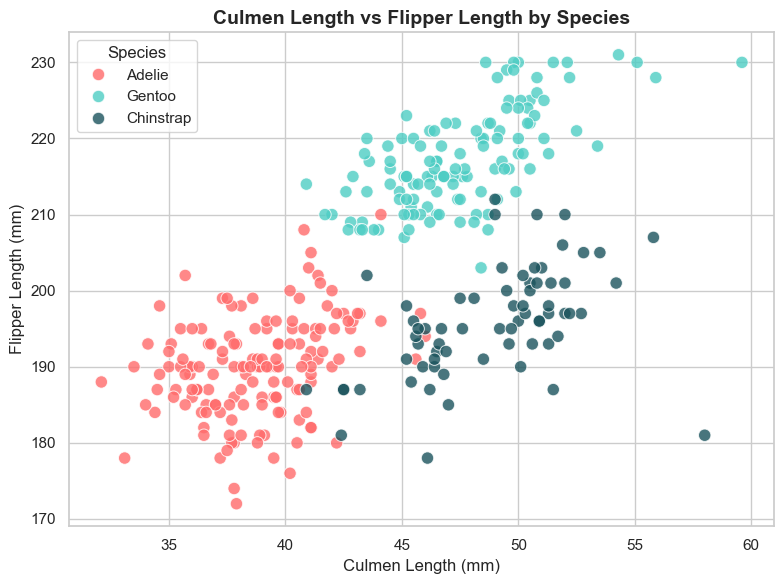

In [30]:
palette = {
    'Adelie': '#FF6B6B',
    'Gentoo': '#4ECDC4',
    'Chinstrap': '#1A535C'
}

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins,
    x='Culmen Length (mm)',
    y='Flipper Length (mm)',
    hue='Species',
    palette=palette,
    s=80,
    alpha=0.8
)

plt.title('Culmen Length vs Flipper Length by Species', fontsize=14, weight='bold')
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.legend(title='Species')

plt.tight_layout()
plt.show()

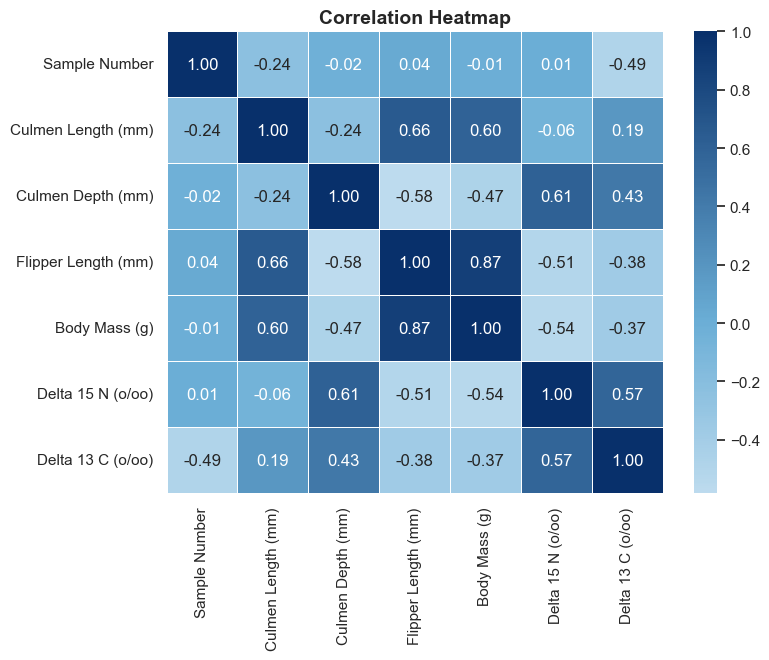

In [33]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "soft_green_blue",
    ['#f7fbff', '#6baed6', '#08306b']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    penguins.corr(numeric_only=True),
    annot=True,
    cmap=custom_cmap,
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title('Correlation Heatmap', fontsize=14, weight='bold')
plt.show()